In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

In [4]:
salex_file = "lexicons/salex_nrc.csv"

emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()


In [5]:
SALEX = pd.read_csv(salex_file).set_index('term_str')
SALEX.columns = [col.replace('nrc_','') for col in SALEX.columns]
SALEX

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
young,0,1,0,0,1,0,1,0,1,0,1
youth,1,1,0,1,1,0,1,0,1,0,1
zeal,0,1,0,0,1,0,1,0,1,1,1


In [7]:
USA = pd.read_csv('data/United_States_of_America_1992_tokens.csv')

TOKENS_SA = USA.join(SALEX, on='term_str', how='left') #.fillna(0)
TOKENS_SA

,Unnamed: 0,country,para_num,sent_num,token_num,token_str,term_str,pos,pos_group,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
0,0,United_States_of_America_1992,0,0,0,United,united,NNP,NN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,1,United_States_of_America_1992,0,0,1,States,states,NNPS,NN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,United_States_of_America_1992,0,0,2,of,of,IN,IN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,United_States_of_America_1992,0,0,3,America,america,NNP,NN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,United_States_of_America_1992,0,0,4,1789,1789,CD,CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7710,7710,United_States_of_America_1992,0,174,13,appropriate,appropriate,JJ,JJ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7711,7711,United_States_of_America_1992,0,174,14,legislation,legislation,NN,NN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7712,7712,United_States_of_America_1992,0,175,0,Amendment,amendment,NNP,NN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7713,7713,United_States_of_America_1992,0,175,1,XXVII,xxvii,NNP,NN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
TOKENS_SA[emo_cols] = TOKENS_SA[emo_cols].fillna(0)

In [10]:
doc_scores = TOKENS_SA[emo_cols].sum().to_frame(name='raw_count')

# Normalize by total matched tokens so scores are comparable across documents
n_matched = TOKENS_SA[emo_cols].any(axis=1).sum()
doc_scores['normalized'] = doc_scores['raw_count'] / n_matched
display(doc_scores)

,raw_count,normalized
anger,118.0,0.165266
anticipation,198.0,0.277311
disgust,104.0,0.145658
fear,118.0,0.165266
joy,172.0,0.240896
sadness,102.0,0.142857
surprise,56.0,0.078431
trust,513.0,0.718487
sentiment,303.0,0.424370


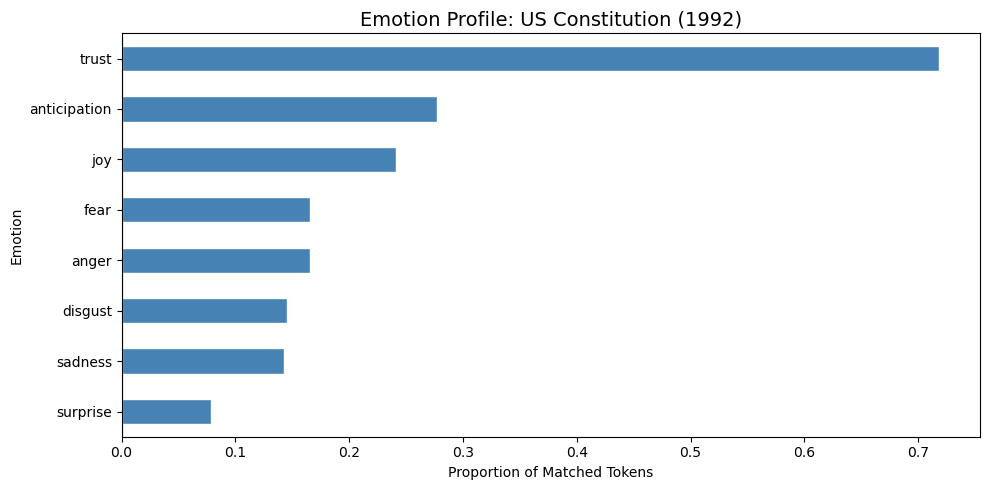

In [12]:
import os

os.mkdir("figures")
fig, ax = plt.subplots(figsize=(10, 5))

emotion_cols = [c for c in emo_cols if c != 'sentiment']  # plot emotions separately

doc_scores.loc[emotion_cols, 'normalized'].sort_values(ascending=True).plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('Emotion Profile: US Constitution (1992)', fontsize=14)
ax.set_xlabel('Proportion of Matched Tokens')
ax.set_ylabel('Emotion')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('figures/usa_emotion_profile.png', dpi=150)
plt.show()

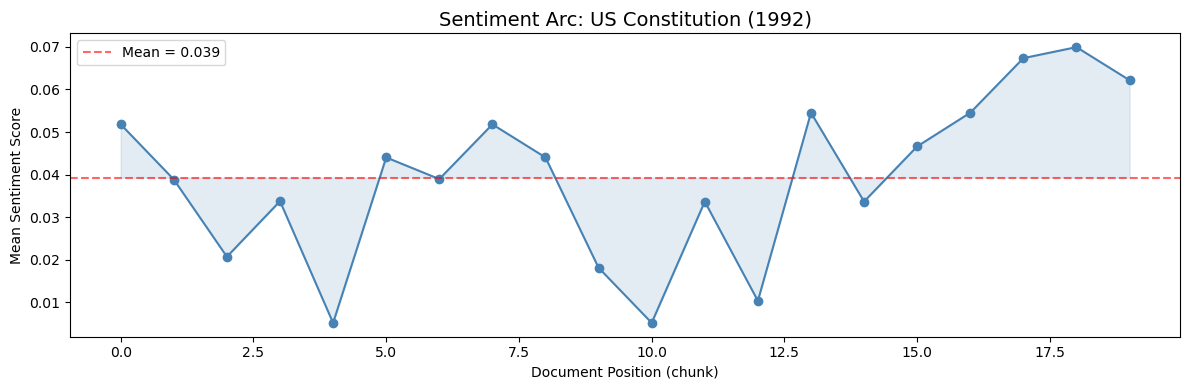

In [13]:
N_CHUNKS = 20

TOKENS_SA = TOKENS_SA.reset_index(drop=True)
TOKENS_SA['chunk'] = pd.cut(TOKENS_SA.index, bins=N_CHUNKS, labels=range(N_CHUNKS))

sentiment_arc = (
    TOKENS_SA.groupby('chunk', observed=True)['sentiment']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sentiment_arc['chunk'], sentiment_arc['sentiment'], marker='o', color='steelblue')
ax.axhline(sentiment_arc['sentiment'].mean(), color='red', linestyle='--', alpha=0.6,
           label=f"Mean = {sentiment_arc['sentiment'].mean():.3f}")
ax.fill_between(sentiment_arc['chunk'], sentiment_arc['sentiment'],
                sentiment_arc['sentiment'].mean(), alpha=0.15, color='steelblue')
ax.set_title('Sentiment Arc: US Constitution (1992)', fontsize=14)
ax.set_xlabel('Document Position (chunk)')
ax.set_ylabel('Mean Sentiment Score')
ax.legend()
plt.tight_layout()
plt.savefig('figures/usa_sentiment_arc.png', dpi=150)
plt.show()

In [14]:
def top_words_for_emotion(tokens_df, emotion, n=15):
    """Return the most frequent tokens that carry a given emotion."""
    mask = tokens_df[emotion] > 0
    return (
        tokens_df.loc[mask, 'term_str']
        .value_counts()
        .head(n)
        .rename(emotion)
    )


In [15]:
for emotion in ['trust', 'fear', 'joy', 'anger']:
    print(f"\n--- Top words: {emotion.upper()} ---")
    print(top_words_for_emotion(TOKENS_SA, emotion).to_string())



--- Top words: TRUST ---
term_str
president    110
share         89
united        86
congress      60
vote          16
majority      14
provide       12
authority      8
judicial       7
money          6
elect          6
officer        6
present        5
oath           5
ballot         5

--- Top words: FEAR ---
term_str
case          13
enforce        9
government     8
treason        7
court          7
death          6
militia        6
war            6
rebellion      5
punishment     4
prohibited     4
highest        3
criminal       2
bear           2
execution      2

--- Top words: JOY ---
term_str
share        89
vote         16
majority     14
money         6
present       5
pay           4
grant         4
highest       3
liberty       3
peace         3
enjoy         2
comfort       2
exceed        2
blessings     1
good          1

--- Top words: ANGER ---
term_str
vote            16
enforce          9
treason          7
court            7
death            6
money            6